# Predicting F1 race standings based on previous races and free practice sessions
The goal of this would be to predict both qualifying and race standings

In [14]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import concurrent.futures
import time
import threading

import fastf1
import logging

print('torch:', torch.__version__, '| cuda:', torch.cuda.is_available())
print('fastf1:', fastf1.__version__)

fastf1.Cache.enable_cache('../data/formula-1')

torch: 2.11.0+cpu | cuda: False
fastf1: 3.8.3


# Model 1: Naive version

**Inputs:** 15 features, 5 per free practice session (FP1 / FP2 / FP3):
- `delta` - driver's best lap as a % gap to the session fastest (0% = quickest car on track)
- `compound` - tyre compound on that lap (0=Soft, 1=Medium, 2=Hard, 3=Inter, 4=Wet)
- `tyre_life` - how many laps the tyre had done before that fastest lap
- `track_temp` - mean track temperature during the session (C)
- `rainfall` - whether it rained at any point in the session (0/1)

**Output:**  predicted qualifying `delta`, which is how far behind the session best the driver will be in Q1, as a % of the fastest lap time

**Architecture:**  MLP, 4 layers:
```
Linear(15-->128) --> BatchNorm --> ReLU --> Dropout(0.3)
Linear(128-->64) --> BatchNorm --> ReLU --> Dropout(0.2)
Linear(64-->32)  --> ReLU
Linear(32-->1)
```
Trained with Adam (lr=1e-3, weight_decay=1e-4) + ReduceLROnPlateau for 2000 epochs. Evaluated with Spearman ρ (rank correlation)

**Results:** On average, ρ ~ 0.9, pretty good

In [ ]:
fastf1.Cache.offline_mode(True)
logging.getLogger("fastf1").setLevel(logging.CRITICAL)

# SOFT/MEDIUM/HARD: relative grip within the weekend (0=softest, 2=hardest).
COMPOUND_MAP = {'SOFT': 0, 'MEDIUM': 1, 'HARD': 2, 'INTERMEDIATE': 3, 'WET': 4}

class RateLimiter:
    def __init__(self, calls_per_hour):
        self._interval = 3600 / calls_per_hour
        self._lock = threading.Lock()
        self._last = 0.0

    def wait(self):
        with self._lock:
            gap = self._interval - (time.monotonic() - self._last)
            if gap > 0:
                time.sleep(gap)
            self._last = time.monotonic()

_limiter = RateLimiter(calls_per_hour=150)

def session_features(session):
    """Per-driver: % gap to session best, compound, tyre_life. Weather from session mean."""
    laps = session.laps.pick_quicklaps()
    idx = laps.groupby('Driver')['LapTime'].idxmin()
    fastest = laps.loc[idx].set_index('Driver')

    session_best = fastest['LapTime'].dt.total_seconds().min()
    lap_times = fastest['LapTime'].dt.total_seconds()

    df = pd.DataFrame(index=fastest.index)
    df['delta']     = (lap_times - session_best) / session_best * 100  # % of a lap
    df['compound']  = fastest['Compound'].map(COMPOUND_MAP).fillna(1).astype(float)
    df['tyre_life'] = fastest['TyreLife'].fillna(0).astype(float)

    if session.weather_data is not None and len(session.weather_data) > 0:
        df['track_temp'] = float(session.weather_data['TrackTemp'].mean())
        df['rainfall']   = float(session.weather_data['Rainfall'].any())
    else:
        df['track_temp'] = float('nan')
        df['rainfall']   = 0.0

    return df, session_best

def load_event(year, round_num, event_name):
    session_data, session_bests = {}, {}
    for name, label in [('FP1', 'fp1'), ('FP2', 'fp2'), ('FP3', 'fp3'), ('Q', 'q')]:
        try:
            s = fastf1.get_session(year, round_num, name)
            _limiter.wait()
            s.load(telemetry=False, weather=True, messages=False)
            feats, best = session_features(s)
            session_data[label] = feats
            session_bests[label] = best
        except Exception:
            return None

    common = session_data['fp1'].index
    for d in session_data.values():
        common = common.intersection(d.index)
    if len(common) == 0:
        return None

    rows = []
    for driver in common:
        row = {'year': year, 'event': event_name, 'driver': driver}
        for label in ('fp1', 'fp2', 'fp3'):
            f = session_data[label].loc[driver]
            row[f'{label}_delta']      = f['delta']
            row[f'{label}_compound']   = f['compound']
            row[f'{label}_tyre_life']  = f['tyre_life']
            row[f'{label}_track_temp'] = f['track_temp']
            row[f'{label}_rainfall']   = f['rainfall']
        row['q_delta'] = session_data['q'].loc[driver, 'delta']
        rows.append(row)

    return (year, event_name, pd.DataFrame(rows))

events = []
for year in range(2018, 2026):
    schedule = fastf1.get_event_schedule(year, include_testing=False)
    for _, event in schedule.iterrows():
        events.append((year, int(event['RoundNumber']), event['EventName']))

rows = []
with concurrent.futures.ThreadPoolExecutor(max_workers=1) as pool:
    futures = {pool.submit(load_event, y, r, n): (y, n) for y, r, n in events}
    for future in concurrent.futures.as_completed(futures):
        result = future.result()
        if result is not None:
            year, event_name, merged = result
            rows.append(merged)
            print(f'{year} {event_name}: {len(merged)} drivers')

all_data = pd.concat(rows, ignore_index=True)
print(f'\nTotal rows: {len(all_data)}')
all_data.head()

In [ ]:
all_data.groupby('event').size()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

FEATURE_COLS = [
    'fp1_delta', 'fp2_delta', 'fp3_delta',
    'fp1_compound', 'fp2_compound', 'fp3_compound',
    'fp1_tyre_life', 'fp2_tyre_life', 'fp3_tyre_life',
    'fp1_track_temp', 'fp2_track_temp', 'fp3_track_temp',
    'fp1_rainfall', 'fp2_rainfall', 'fp3_rainfall',
]

X_raw = all_data[FEATURE_COLS].fillna(0).values
y_raw = all_data['q_delta'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_raw, test_size=0.2, random_state=42)

print(f'Train: {len(X_train)}  Val: {len(X_val)}  Features: {X_train.shape[1]}')

In [ ]:
class QualiNetwork(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

In [ ]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu" # type: ignore
print(f"Using {device} device")

model = QualiNetwork(in_features=len(FEATURE_COLS)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=150, factor=0.5, min_lr=1e-5)

In [ ]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32).to(device)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32).to(device)

train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(X_train_t, y_train_t),
    batch_size=64, shuffle=True
)

In [ ]:
num_epochs = 2000
loss_history = {'train': [], 'val': []}

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_loss = epoch_loss / len(train_loader)

    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_val_t), y_val_t).item()

    loss_history['train'].append(train_loss)
    loss_history['val'].append(val_loss)
    scheduler.step(val_loss)

    if (epoch + 1) % 200 == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch+1:4d}  train={train_loss:.4f}  val={val_loss:.4f}  lr={lr:.2e}')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(loss_history['train'], label='train')
axes[0].plot(loss_history['val'], label='val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training vs validation loss')
axes[0].legend()

# Zoom in after warmup
axes[1].plot(loss_history['train'][200:], label='train')
axes[1].plot(loss_history['val'][200:], label='val')
axes[1].set_xlabel('Epoch (after 200)')
axes[1].set_title('Loss (zoomed)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import spearmanr

model.eval()
with torch.no_grad():
    X_all_t = torch.tensor(X_scaled, dtype=torch.float32).to(device)
    pred = model(X_all_t).cpu().numpy()

results = all_data[['year', 'event', 'driver', 'q_delta']].copy()
results['pred_delta'] = pred

# Spearman rank correlation per event — 1.0 = perfect order, 0 = random
def event_spearman(df):
    r, _ = spearmanr(df['q_delta'], df['pred_delta'])
    return round(r, 3)

corr = results.groupby(['year', 'event']).apply(event_spearman, include_groups=False).rename('spearman_r')
print(f'Mean Spearman ρ: {corr.mean():.3f}  (1.0 = perfect ranking)')
corr.sort_values()

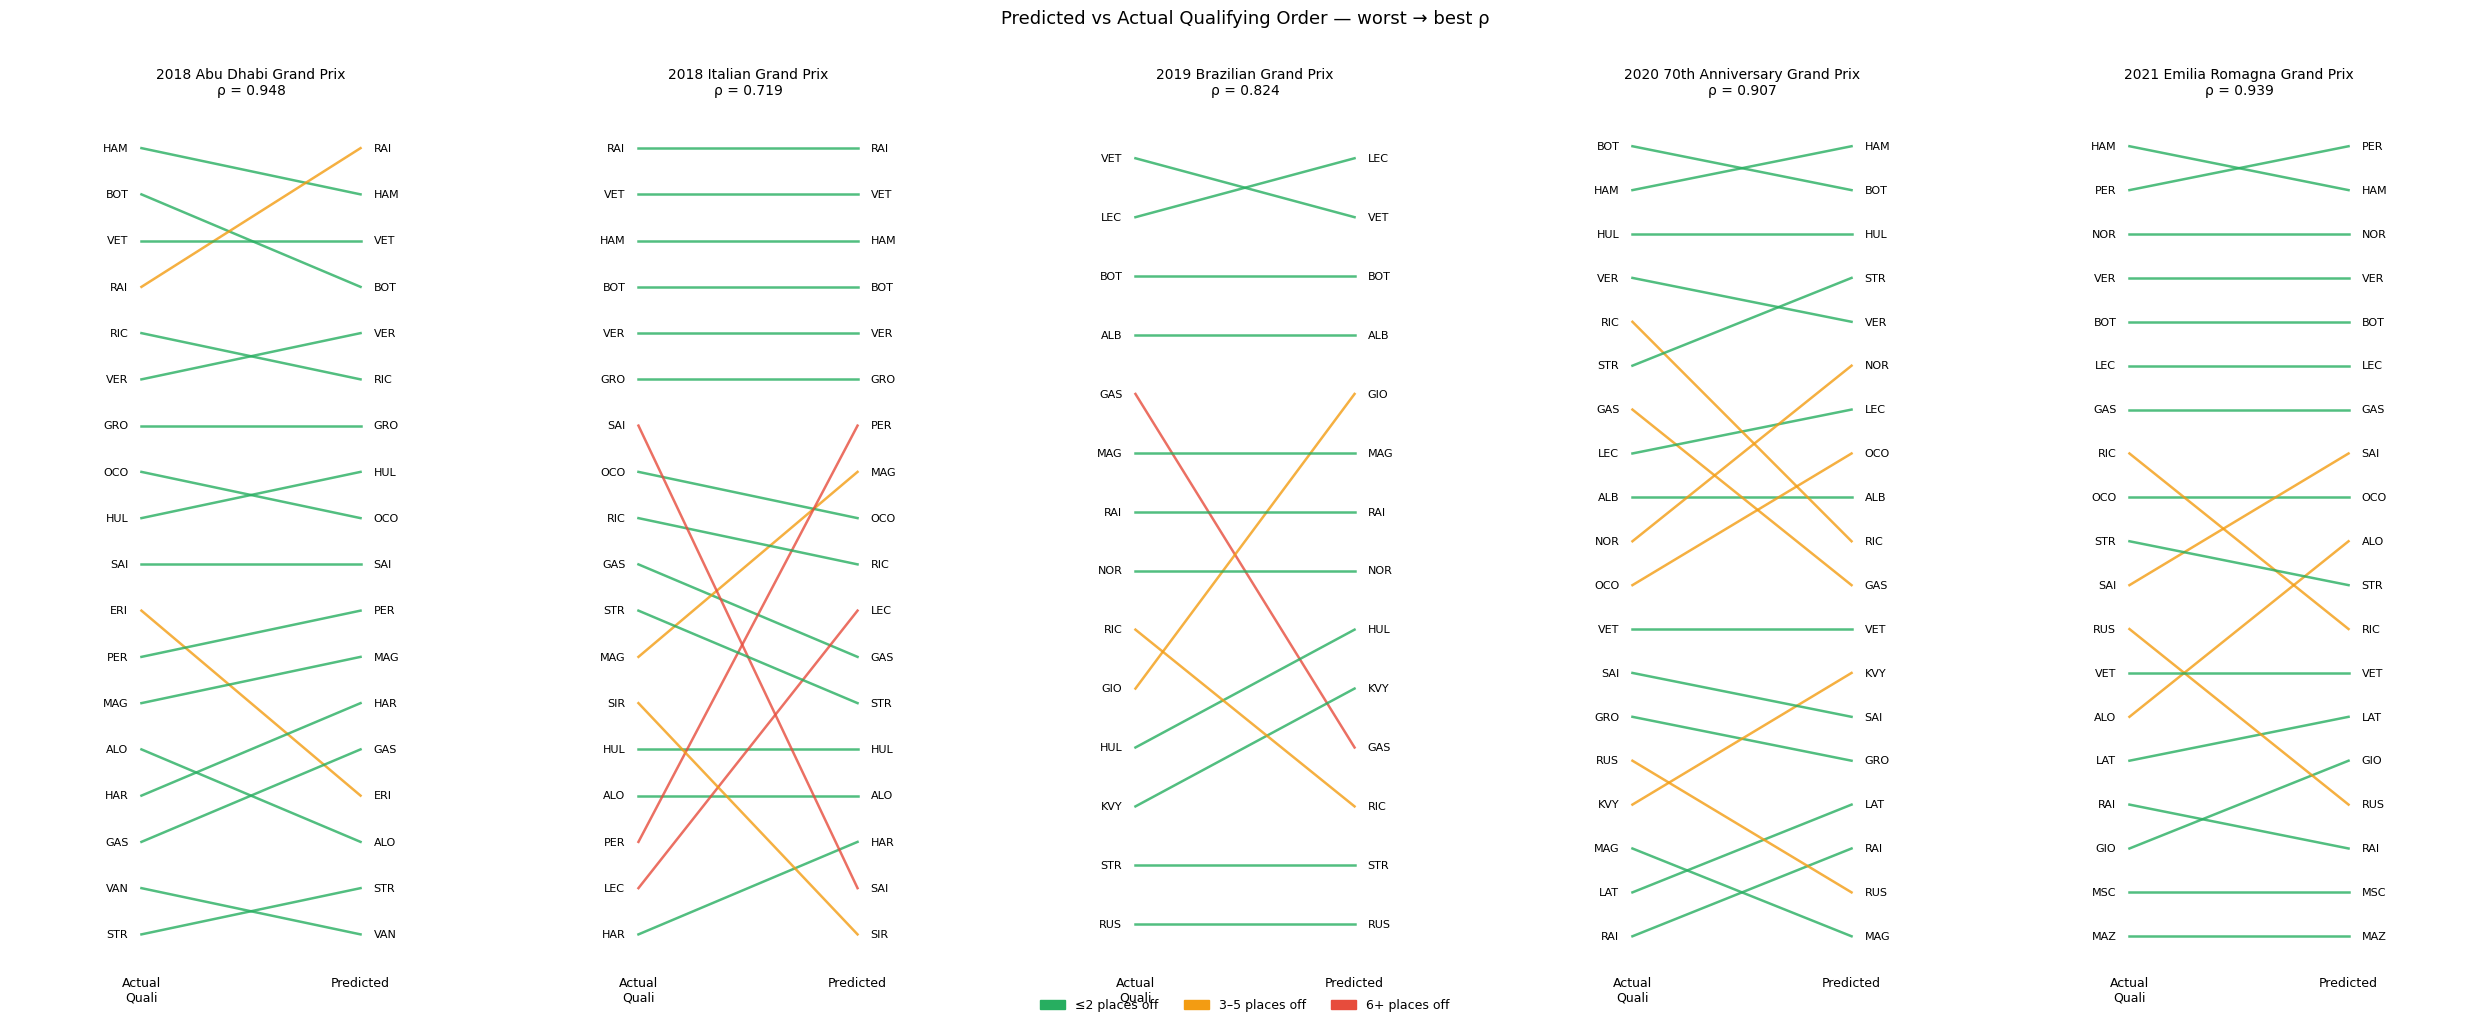

In [ ]:
# Bump chart: actual qualifying rank (left) vs predicted rank (right)
# Green lines = model was within 2 places, orange = 3-5 off, red = 6+ off

corr_df = corr.reset_index()
n_bins = 5
indices = [int(i * (len(corr_df) - 1) / (n_bins - 1)) for i in range(n_bins)]
selected = corr_df.iloc[sorted(indices)]

fig, axes = plt.subplots(1, n_bins, figsize=(5 * n_bins, 10))

for ax, (_, row) in zip(axes, selected.iterrows()):
    ev = results[(results['year'] == row['year']) & (results['event'] == row['event'])].copy()
    ev['actual_rank'] = ev['q_delta'].rank(method='first').astype(int)
    ev['pred_rank']   = ev['pred_delta'].rank(method='first').astype(int)
    n = len(ev)

    for _, d in ev.iterrows(): # pyright: ignore[reportGeneralTypeIssues]
        diff = abs(d['actual_rank'] - d['pred_rank'])
        color = '#27ae60' if diff <= 2 else '#e74c3c' if diff >= 6 else '#f39c12'
        ax.plot([0, 1], [d['actual_rank'], d['pred_rank']], color=color, lw=1.8, alpha=0.8)
        ax.text(-0.06, d['actual_rank'], d['driver'], ha='right', va='center', fontsize=8)
        ax.text( 1.06, d['pred_rank'],   d['driver'], ha='left',  va='center', fontsize=8)

    ax.set_xlim(-0.6, 1.6)
    ax.set_ylim(0.2, n + 0.8)
    ax.invert_yaxis()
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Actual\nQuali', 'Predicted'], fontsize=9)
    ax.set_title(f"{int(row['year'])} {row['event']}\nρ = {row['spearman_r']:.3f}", fontsize=10, pad=12)
    ax.yaxis.set_visible(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(length=0)

legend_patches = [
    mpatches.Patch(color='#27ae60', label='≤2 places off'),
    mpatches.Patch(color='#f39c12', label='3–5 places off'),
    mpatches.Patch(color='#e74c3c', label='6+ places off'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3, fontsize=9, frameon=False)
plt.suptitle('Predicted vs Actual Qualifying Order — worst --> best ρ', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()